In [304]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import requests
import tqdm
from matplotlib import pyplot as plt
import random
import os

In [305]:
# Load the data, using tiny shakespeare
input_file_path = '../data/tinyshakespeare.txt'
data_url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

if not os.path.exists(input_file_path):
    with open(input_file_path, 'w') as f:
        f.write(requests.get(data_url).text)
    
with open(input_file_path, 'r') as f:
    corpus = f.read()

In [306]:
# Character level "tokenizer"
unique_chars = sorted(list(set(corpus)))

stoi = {ch: i for i, ch in enumerate(unique_chars)} # str to int
itos = {i: ch for i, ch in enumerate(unique_chars)} # int to str

def encode(text: str) -> list[int]:
    return [stoi[char] for char in text]

def decode(tokens: list[int]) -> str:
    return ''.join([itos[token] for token in tokens])

# Encode the corpus and convert to tesnor
data = torch.tensor(encode(corpus), dtype=torch.long)

In [307]:
# Split the data
n = len(data)
train_frac = int(0.9 * n)
train_data = data[:train_frac]
test_data = data[train_frac:]

In [308]:
# Get batches
def get_batch(data, batch_size: int, seq_len: int):
    """Get a batch of (x, y) data from the corpus

    Args:
        data: 1D tensor of torch.long containing the corpus tokens
        batch_size (int): The number of samples to get
        seq_len (int): The length of each sequence to fetch
        
    Returns:
        X: a 2D tensor of shape (batch_size, seq_len) containing token IDs
        Y: a 2D tensor of shape (batch_size, seq_len) containing token IDs
    """
    n = len(data)
    if seq_len > n:
        raise ValueError('seq_len is larger than size of corpus')
    
    start_idxs = torch.randint(n - seq_len, (batch_size,))
    start_idxs = start_idxs[:, None]
    range_idxs = torch.arange(seq_len + 1)
    idxs = start_idxs + range_idxs
    
    values = data[idxs]
    X, Y = values[:, :-1], values[:, 1:]
    return X, Y

In [309]:
# Train the model
vocab_size = len(unique_chars)
batch_size = 64
seq_len = 32
total_steps = 5000

model = nn.Embedding(vocab_size, vocab_size)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1.e-3)

losses = []
seq_done = 0

pbar = tqdm.tqdm(range(total_steps))
for step in pbar:
    x, y = get_batch(train_data, batch_size, seq_len)
    optimizer.zero_grad()
    
    logits = model(x)
    logits = logits.reshape(-1, logits.size(-1))
    y = y.reshape(-1)
    
    loss = criterion(logits, y)
    loss.backward()
    
    losses.append(loss.item())
    seq_done += batch_size
    
    pbar.set_description(f'Loss: {loss.item():.4f}, Sequences Done: {seq_done}')
    
    optimizer.step()
    

Loss: 2.5038, Sequences Done: 320000: 100%|██████████| 5000/5000 [00:04<00:00, 1124.52it/s]


Text(0, 0.5, 'Loss')

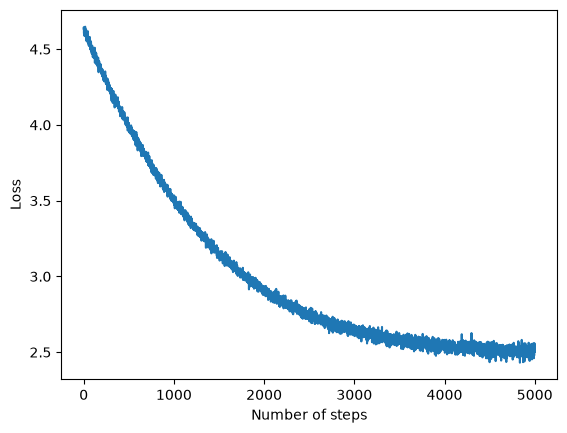

In [310]:
# Graph the results
plt.plot(np.linspace(0, total_steps-1, total_steps), losses)
plt.xlabel('Number of steps')
plt.ylabel('Loss')

In [311]:
# Autoregressive generation
tokens_to_gen = 200
random_char = unique_chars[random.randint(0, vocab_size-1)]
start_token = encode(random_char)[0]

generated_tokens = []
generated_tokens.append(start_token)

for _ in range(tokens_to_gen-1):
    prev_token = torch.tensor(generated_tokens[-1])
    logits = model(prev_token)
    probs = F.softmax(logits, dim=-1)
    token = torch.multinomial(probs, num_samples=1) # Sampling
    generated_tokens.append(token.item())
    
decode(generated_tokens)


"Winel.\nQUSI nole sEY$He; f ? neemy t ororer I tGBese d me;nkZZds heshemantyot has l's:\nKIUMareeander bond nt fote igiverrerthe:\nYORD h we sthy Ifat orfomeee ta be\nHMyel h han iel INDYosocapad, thLLI p"